In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def my_hessenberg(A):
    # reduces A to upper Hessenberg form
    n = A.shape[0]
    H = A.copy()
    Q = np.eye(n)
    for k in range(n)

SyntaxError: invalid syntax (<ipython-input-2-b91d8e1ee492>, line 6)

## Implicit QR algorithm

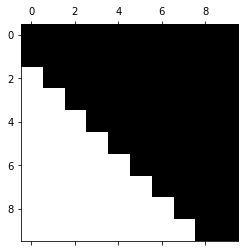

In [2]:
A = np.random.randn(10,10)+1j*np.random.randn(10,10)

# reduce A to Hessenberg form

from scipy.linalg import hessenberg

A = hessenberg(A)

plt.spy(A,precision=1e-5)

In [3]:
# step 1: produce a zero in the (2,1) position using complex rotator.

x = A[[0,1],0]
c = x[0].conj()
s = x[1].conj()

rotator = np.array([[c,s],[-x[1],x[0]]])/np.linalg.norm(x)

#multiply A by Q from the left

A[[0,1],:] = rotator.dot(A[[0,1],:])

#multiply A by Q^* from the right

A[:,[0,1]] = A[:,[0,1]].dot(rotator.conj().T)

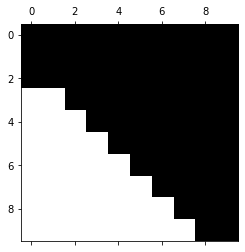

In [4]:
plt.spy(A,precision=1e-5)

In [5]:
i = 0
# build the rotator

x = A[[i+1,i+2],i]
rotator  =np.array([
    [x[0].conj(),x[1].conj()],
    [-x[1],x[0]]
])/np.linalg.norm(x)

In [6]:
A[[i+1,i+2]] = rotator.dot(A[[i+1,i+2]])

A[:,[i+1,i+2]] = A[:,[i+1,i+2]].dot(rotator.conj().T)

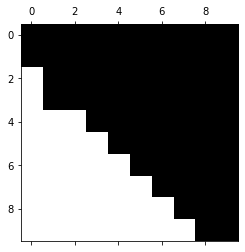

In [7]:
plt.spy(A,precision=1e-5)

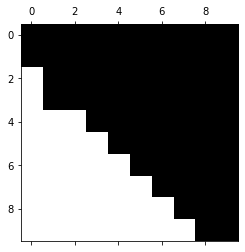

In [8]:
x = A[[i+1,i+2],i]
rotator  =np.array([
    [x[0].conj(),x[1].conj()],
    [-x[1],x[0]]
])/np.linalg.norm(x)

A[[i+1,i+2]] = rotator.dot(A[[i+1,i+2]])

A[:,[i+1,i+2]] = A[:,[i+1,i+2]].dot(rotator.conj().T)

i+=1
plt.spy(A,precision=1e-5)

In [9]:
A = np.random.randn(10,10)+1j*np.random.randn(10,10)


A = hessenberg(A)

In [10]:
max_iter = 100
for it in range(max_iter):

SyntaxError: unexpected EOF while parsing (<ipython-input-10-39c535f5acf9>, line 2)

In [1]:
def my_eig(A):
    n = A.shape[0]
    H = A.copy()
    for j in range(1,n):
        while np.abs(H[n-1,n-2])>1e-16*(np.abs(H[n-2,n-2])+np.abs(H[n-1,n-1])):
            shift = H[n-1,n-1]
            #print(np.abs(shift))
            x = H[[0,1],0]-np.array([shift,0])
            rotator = np.array([[x[0].conj(),x[1].conj()],
                            [-x[1],x[0]]])/np.linalg.norm(x)
            # multiply by the rotator from the left
            H[[0,1]] = rotator.dot(H[[0,1]])
            # multiply by the rotator from the right
            H[:,[0,1]] = H[:,[0,1]].dot(rotator.conj().T)
            for i in range(n-2):
                # build the rotator
                x = H[[i+1,i+2],i]
                rotator = np.array([[x[0].conj(),x[1].conj()],
                            [-x[1],x[0]]])/np.linalg.norm(x)
                # multiply by the rotator from the left
                H[[i+1,i+2]] = rotator.dot(H[[i+1,i+2]])
                # multiply by the rotator from the right
                H[:,[i+1,i+2]] = H[:,[i+1,i+2]].dot(rotator.conj().T)
        n = n-1
    evalues = np.diag(H)
    # eigenvectors
    n = A.shape[0]
    evectors = np.random.randn(n,n)
    for i in range(n):
        # apply two iterations of shift-and-invert
        np.linalg.solve(A-evalues[i]*np.eye(n), evector)
    

## QR algorithm of degree 2 (for computing eigenvalues of real matrices)

In [7]:
def my_eig_real(A):
    # computes eigenvalues and eigenvectors of a real matrix A
    from scipy.linalg import hessenberg
    n = A.shape[0]
    H = A.copy()
    H = hessenberg(H)
    
    def get_eigenvalues(H):
        n = H.shape[0]
    
        if n==1:
            return H[0,0]
        elif n==2:
            b = H[0,0]+H[1,1]
            c = H[0,0]*H[1,1]-H[1,0]*H[0,1]
            return np.roots([1,-b,c])
            
            
        else:
            while True:
                
                for i in range(1,n):
                    if np.abs(H[i,i-1])<1e-16*(np.abs(H[i-1,i-1])+np.abs(H[i,i])):
                        H1 = H[0:i,0:i].copy()
                        H2 = H[i:n,i:n].copy()

                        eig1 = get_eigenvalues(H1)
                        eig2 = get_eigenvalues(H2)
                        return np.append(eig1,eig2)
            
                # column 1 of (A-sigma_1 I)(A-sigma_2 I)
                t = H[n-2,n-2]*H[n-1,n-1]- H[n-2,n-1]*H[n-1,n-2]# sigma1*sigma2
                s = H[n-2,n-2]+H[n-1,n-1]# sigma1+sigma2
                a = H[0,0]**2+H[0,1]*H[1,0]-s*H[0,0]+t
                b = H[1,0]*(H[0,0]+H[1,1]-s)
                c = H[1,0]*H[2,1]

                # build the reflector
                x = np.array([[a],[b],[c]])
                norm_x = np.linalg.norm(x)
                if norm_x <1e-16:
                    gamma = 0
                else:
                    tau = np.sign(x[0])*norm_x
                    gamma = (x[0]+tau)/tau
                    x[1:]=x[1:]/(x[0]+tau)
                    x[0] = 1
                # multiply by the reflector
                H[[0,1,2]] = H[[0,1,2]] - gamma*x.dot(x.T.dot(H[[0,1,2]]))
                H[:,[0,1,2]] = H[:,[0,1,2]] - gamma*(H[:,[0,1,2]].dot(x)).dot(x.T)

                for j in range(n-3):
                    x = H[[j+1,j+2,j+3],[j]].reshape(3,1)
                    # build the reflector
                    norm_x = np.linalg.norm(x)
                    if norm_x <1e-16:
                        gamma = 0
                    else:
                        tau = np.sign(x[0])*norm_x
                        gamma = (x[0]+tau)/tau
                        x[1:]=x[1:]/(x[0]+tau)
                        x[0] = 1
                    # multiply by the reflector
                    H[[j+1,j+2,j+3]] = H[[j+1,j+2,j+3]] - gamma*x.dot(x.T.dot(H[[j+1,j+2,j+3]]))
                    H[:,[j+1,j+2,j+3]] = H[:,[j+1,j+2,j+3]] - gamma*(H[:,[j+1,j+2,j+3]].dot(x)).dot(x.T)
                # build a rotator
                x = H[[n-2,n-1],n-3]
                rotator = np.array([[x[0],x[1]],[-x[1],x[0]]])/np.linalg.norm(x)
                H[[n-2,n-1]] = rotator.dot(H[[n-2,n-1]])
                H[:,[n-2,n-1]] = H[:,[n-2,n-1]].dot(rotator.T)
                
    
    eigvalues = get_eigenvalues(H)
    return eigvalues

In [10]:
A = np.random.randn(3,3)


my_eig_real(A)

array([ 0.5020496 +1.14510358j,  0.5020496 -1.14510358j,
       -1.42441146+0.j        ])

In [11]:
np.linalg.eig(A)[0]

array([ 0.5020496 +1.14510358j,  0.5020496 -1.14510358j,
       -1.42441146+0.j        ])